# 04e — Economic Appraisal

**Purpose:** BCR calculations (Green Book / TAG v2.03fc methodology), investment gap analysis,
modal shift modelling, and carbon reduction quantification. Every constant traces to a
✅ Confirmed figure in the figures registry.

**Inputs:**
- `data/audit/tag_constants.json` — TAG v2.03fc VoT, carbon appraisal, social discount rate
- `data/audit/desnz_carbon_factors.json` — DESNZ 2025 CO2 emission factors
- `data/audit/lsoa_service_quality.parquet` — SQI, headway, departures per LSOA
- `data/audit/lsoa_equity_metrics.parquet` — trips per capita, vulnerability index
- `data/audit/master_lsoa_table.parquet` — population, IMD, socio-economic factors
- `data/audit/top_500_transport_deserts.csv` — priority LSOAs for BCR analysis
- `data/audit/route_geometries.parquet` — route lengths (for trip distance estimate)

**Outputs:**
- `data/audit/lsoa_economic_appraisal.parquet` — per-LSOA BCR estimates, investment gap
- `data/audit/modal_shift_scenarios.parquet` — carbon and cost impact of modal shift scenarios

## 1. Load and Verify Constants

In [1]:
import json
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
from loguru import logger

warnings.filterwarnings("ignore", category=FutureWarning)

DATA_AUDIT = Path("../data/audit")
FIGURES_DIR = Path("../data/audit/figures")
FIGURES_DIR.mkdir(exist_ok=True)

In [2]:
with open(DATA_AUDIT / "tag_constants.json") as f:
    TAG = json.load(f)

with open(DATA_AUDIT / "desnz_carbon_factors.json") as f:
    DESNZ = json.load(f)

logger.info(f"TAG version: {TAG['version']}, published: {TAG['published']}")
logger.info(f"DESNZ published: {DESNZ['published']}")

2026-03-14 15:21:00.762 | INFO     | __main__:<module>:7 - TAG version: v2.03fc, published: December 2025


2026-03-14 15:21:00.762 | INFO     | __main__:<module>:8 - DESNZ published: June 2025


In [3]:
# --- Confirmed constants used throughout ---
# VoT: use 2023 prices from A1.3.1 (commuting + leisure weighted average for bus passengers)
# Bus trips are predominantly commuting (~40%) + leisure (~50%) + business (~10%) — DfT NTS split
VOT_COMMUTING_2023 = TAG["value_of_time"]["a131_published_2023_prices"]["commuting_factor_cost_per_hr"]  # £13.01
VOT_LEISURE_2023   = TAG["value_of_time"]["a131_published_2023_prices"]["leisure_factor_cost_per_hr"]    # £5.94
VOT_BUS_PSV_2023   = TAG["value_of_time"]["a131_published_2023_prices"]["working_factor_cost"]["PSV passenger"]  # £13.10 (business)

# Weighted blended VoT for bus passengers (DfT NTS 2023 trip purpose split for bus)
# Commuting 38%, Leisure/other 51%, Business 11%
VOT_BUS_BLENDED = 0.38 * VOT_COMMUTING_2023 + 0.51 * VOT_LEISURE_2023 + 0.11 * VOT_BUS_PSV_2023
logger.info(f"Blended bus VoT: £{VOT_BUS_BLENDED:.2f}/hr")

SOCIAL_DISCOUNT_RATE = TAG["social_discount_rate"]  # 3.5%
CARBON_PRICE_2025    = TAG["carbon_appraisal"]["central_2025"]  # £259.87/tCO2e (2020 prices)

# DESNZ emission factors
BUS_CO2_KG_PAX_KM  = DESNZ["bus"]["average_local_bus"]["value"]      # 0.10385 kg/pax-km
CAR_CO2_KG_VEH_KM  = DESNZ["car"]["average_car_diesel_per_vehicle_km"]["value"]  # 0.17304
CAR_CO2_KG_PAX_KM  = DESNZ["car"]["average_car_per_passenger_km"]["value"]       # 0.11164
CAR_OCCUPANCY      = DESNZ["car"]["occupancy_assumption"]["value"]                # 1.55
MODAL_SHIFT_SAVING = DESNZ["modal_shift_car_to_bus"]["saving_per_pax_km"]         # 0.00779 kg/pax-km

# Route operating costs — indicative, not DfT-sourced (flagged as ❌ Unverified)
COST_PER_VEH_KM_URBAN = 4.50   # £/veh-km, industry estimate (Passenger Transport Executive data)
COST_PER_VEH_KM_RURAL = 3.80   # £/veh-km (lower density, lower fuel cost)
AVG_TRIPS_PER_VEH_KM  = 20.0   # passengers per vehicle-km (average local bus load factor ~25%)

# DfT frequency elasticity (DfT Bus Open Data evidence, range 0.4–0.7)
FREQ_ELASTICITY_LOW    = 0.4
FREQ_ELASTICITY_CENTRAL = 0.55
FREQ_ELASTICITY_HIGH   = 0.7

# Appraisal period (Green Book standard: 60 years for transport infrastructure)
APPRAISAL_YEARS = 60

constants_table = pd.DataFrame([
    {"Parameter": "VoT — Commuting (2023 prices)", "Value": f"£{VOT_COMMUTING_2023:.2f}/hr", "Source": "TAG A1.3.1 D46", "Status": "✅ Confirmed"},
    {"Parameter": "VoT — Leisure/Other (2023 prices)", "Value": f"£{VOT_LEISURE_2023:.2f}/hr", "Source": "TAG A1.3.1 D47", "Status": "✅ Confirmed"},
    {"Parameter": "VoT — PSV passenger business (2023)", "Value": f"£{VOT_BUS_PSV_2023:.2f}/hr", "Source": "TAG A1.3.1 D33", "Status": "✅ Confirmed"},
    {"Parameter": "VoT — Blended bus (38% comm, 51% leis, 11% biz)", "Value": f"£{VOT_BUS_BLENDED:.2f}/hr", "Source": "Derived from TAG A1.3.1", "Status": "✅ Confirmed"},
    {"Parameter": "Social discount rate", "Value": "3.5%/yr", "Source": "HM Treasury Green Book 2026", "Status": "✅ Confirmed"},
    {"Parameter": "Carbon appraisal value (central, 2025)", "Value": f"£{CARBON_PRICE_2025:.2f}/tCO2e", "Source": "TAG GHG!E42 (2020 prices)", "Status": "✅ Confirmed"},
    {"Parameter": "Bus CO2 factor (avg local)", "Value": f"{BUS_CO2_KG_PAX_KM:.5f} kg/pax-km", "Source": "DESNZ 2025 D81", "Status": "✅ Confirmed"},
    {"Parameter": "Car CO2 factor (avg diesel, per veh-km)", "Value": f"{CAR_CO2_KG_VEH_KM:.5f} kg/veh-km", "Source": "DESNZ 2025 D53", "Status": "✅ Confirmed"},
    {"Parameter": "Car CO2 factor (per pax-km, ÷1.55)", "Value": f"{CAR_CO2_KG_PAX_KM:.5f} kg/pax-km", "Source": "DESNZ 2025 derived", "Status": "✅ Confirmed"},
    {"Parameter": "Modal shift saving (car→bus)", "Value": f"{MODAL_SHIFT_SAVING:.5f} kg/pax-km", "Source": "DESNZ 2025 derived", "Status": "✅ Confirmed"},
    {"Parameter": "Operating cost — urban (veh-km)", "Value": f"£{COST_PER_VEH_KM_URBAN:.2f}/veh-km", "Source": "Industry estimate", "Status": "❌ Unverified"},
    {"Parameter": "Operating cost — rural (veh-km)", "Value": f"£{COST_PER_VEH_KM_RURAL:.2f}/veh-km", "Source": "Industry estimate", "Status": "❌ Unverified"},
    {"Parameter": "DfT frequency elasticity (central)", "Value": f"{FREQ_ELASTICITY_CENTRAL}", "Source": "DfT Bus Open Data evidence review", "Status": "✅ Confirmed"},
])
print(constants_table.to_string(index=False))

2026-03-14 15:21:00.768 | INFO     | __main__:<module>:11 - Blended bus VoT: £9.41/hr


                                      Parameter             Value                            Source       Status
                  VoT — Commuting (2023 prices)         £13.01/hr                    TAG A1.3.1 D46  ✅ Confirmed
              VoT — Leisure/Other (2023 prices)          £5.94/hr                    TAG A1.3.1 D47  ✅ Confirmed
            VoT — PSV passenger business (2023)         £13.10/hr                    TAG A1.3.1 D33  ✅ Confirmed
VoT — Blended bus (38% comm, 51% leis, 11% biz)          £9.41/hr           Derived from TAG A1.3.1  ✅ Confirmed
                           Social discount rate           3.5%/yr       HM Treasury Green Book 2026  ✅ Confirmed
         Carbon appraisal value (central, 2025)     £259.87/tCO2e         TAG GHG!E42 (2020 prices)  ✅ Confirmed
                     Bus CO2 factor (avg local) 0.10385 kg/pax-km                    DESNZ 2025 D81  ✅ Confirmed
        Car CO2 factor (avg diesel, per veh-km) 0.17304 kg/veh-km                    DESNZ 2025 

In [4]:
# Validation: all ✅ constants must be present
confirmed = constants_table[constants_table["Status"] == "✅ Confirmed"]
unverified = constants_table[constants_table["Status"] == "❌ Unverified"]
assert len(confirmed) >= 10, f"FAIL: expected ≥10 confirmed constants, got {len(confirmed)}"
print(f"CHECK PASS: {len(confirmed)} confirmed constants, {len(unverified)} unverified (operating cost — flagged)")

CHECK PASS: 11 confirmed constants, 2 unverified (operating cost — flagged)


## 2. Load Input Data

In [5]:
sq = pd.read_parquet(DATA_AUDIT / "lsoa_service_quality.parquet").rename(columns={"LSOA21CD": "lsoa_cd"})
eq = pd.read_parquet(DATA_AUDIT / "lsoa_equity_metrics.parquet")
master = pd.read_parquet(DATA_AUDIT / "master_lsoa_table.parquet")
top500 = pd.read_csv(DATA_AUDIT / "top_500_transport_deserts.csv")
routes = pd.read_parquet(DATA_AUDIT / "route_geometries.parquet")

logger.info(f"Service quality: {sq.shape}, equity: {eq.shape}, master: {master.shape}")
logger.info(f"Top 500 deserts: {top500.shape}, routes: {routes.shape}")

2026-03-14 15:21:00.885 | INFO     | __main__:<module>:7 - Service quality: (33755, 28), equity: (33755, 18), master: (33755, 50)


2026-03-14 15:21:00.886 | INFO     | __main__:<module>:8 - Top 500 deserts: (500, 16), routes: (13640, 16)


In [6]:
# Build working dataset — merge service quality, equity, and master
base = (
    master[["lsoa_cd", "lsoa_nm", "lad_cd", "lad_nm", "imd_score", "imd_decile",
            "population", "urban_rural", "region", "nocar_pct", "elderly_pct",
            "unemployment_rate", "disability_pct"]]
    .merge(
        eq[["lsoa_cd", "trips_per_capita", "vulnerability_index",
            "triple_deprived", "quadruple_vulnerable", "service_quality_index"]],
        on="lsoa_cd", how="left"
    )
    .merge(
        sq[["lsoa_cd", "total_weekday_departures", "mean_headway_min",
            "evening_isolated", "sunday_desert"]],
        on="lsoa_cd", how="left"
    )
)

# trips_per_capita nulls → 0 (no service)
base["trips_per_capita"] = base["trips_per_capita"].fillna(0.0)
base["total_weekday_departures"] = base["total_weekday_departures"].fillna(0.0)

assert len(base) == 33_755, f"FAIL: expected 33,755 rows, got {len(base)}"
print(f"CHECK PASS: working dataset {base.shape}")
print(f"  trips_per_capita range: {base['trips_per_capita'].min():.3f} – {base['trips_per_capita'].max():.3f}")
print(f"  imd_decile coverage: {base['imd_decile'].notna().sum()} / {len(base)}")

CHECK PASS: working dataset (33755, 22)
  trips_per_capita range: 0.000 – 22.896
  imd_decile coverage: 33755 / 33755


In [7]:
# Mean route length (from 04a confirmed figure: 23.0 km)
mean_route_length_km = routes["length_km"].mean()
median_route_length_km = routes["length_km"].median()
logger.info(f"Mean route length: {mean_route_length_km:.1f} km (median: {median_route_length_km:.1f} km)")
assert 22.0 <= mean_route_length_km <= 24.0, f"FAIL: mean route length {mean_route_length_km:.1f} outside expected 22–24 km"
print(f"CHECK PASS: mean route length {mean_route_length_km:.1f} km ✅")

# Average trip distance: passengers typically travel 40–60% of route length (DfT NTS 2023)
AVG_TRIP_DISTANCE_KM = median_route_length_km * 0.50  # conservative 50% of median route
logger.info(f"Average trip distance assumed: {AVG_TRIP_DISTANCE_KM:.1f} km")

2026-03-14 15:21:00.906 | INFO     | __main__:<module>:4 - Mean route length: 23.0 km (median: 18.7 km)


2026-03-14 15:21:00.906 | INFO     | __main__:<module>:10 - Average trip distance assumed: 9.4 km


CHECK PASS: mean route length 23.0 km ✅


## 3. Investment Gap Analysis

**Definition:** For each LSOA in the bottom IMD decile, what would it cost to bring
weekday trip provision up to the national median?

In [8]:
national_median_trips = base["trips_per_capita"].median()
national_mean_trips   = base["trips_per_capita"].mean()
logger.info(f"National median trips/capita: {national_median_trips:.4f}")
logger.info(f"National mean trips/capita: {national_mean_trips:.4f}")

# Bottom decile (most deprived) — IMD decile 1
bottom_decile = base[base["imd_decile"] == 1].copy()
logger.info(f"Bottom IMD decile LSOAs: {len(bottom_decile)}")

# Gap = (median - actual) for those BELOW median; 0 for those already at/above median
bottom_decile["trips_gap"] = (national_median_trips - bottom_decile["trips_per_capita"]).clip(lower=0)
bottom_decile["annual_additional_trips"] = bottom_decile["trips_gap"] * bottom_decile["population"] * 250  # weekday-equivalent annual (250 weekdays)

# Cost to provide additional trips — operating cost model
# trip_cost = veh-km cost / passengers per veh-km (load factor)
trip_cost_urban = COST_PER_VEH_KM_URBAN / AVG_TRIPS_PER_VEH_KM * AVG_TRIP_DISTANCE_KM
trip_cost_rural = COST_PER_VEH_KM_RURAL / AVG_TRIPS_PER_VEH_KM * AVG_TRIP_DISTANCE_KM

bottom_decile["is_urban"] = bottom_decile["urban_rural"].str.contains("Urban", na=False)
bottom_decile["cost_per_trip"] = np.where(bottom_decile["is_urban"], trip_cost_urban, trip_cost_rural)
bottom_decile["annual_operating_cost"] = bottom_decile["annual_additional_trips"] * bottom_decile["cost_per_trip"]

# Aggregate
total_additional_trips = bottom_decile["annual_additional_trips"].sum()
total_annual_cost = bottom_decile["annual_operating_cost"].sum()
lsoas_with_gap = (bottom_decile["trips_gap"] > 0).sum()
pop_with_gap = bottom_decile.loc[bottom_decile["trips_gap"] > 0, "population"].sum()

print(f"\n{'='*60}")
print(f"INVESTMENT GAP ANALYSIS — Bottom IMD Decile → National Median")
print(f"{'='*60}")
print(f"  LSOAs in bottom decile:      {len(bottom_decile):,}")
print(f"  LSOAs below national median: {lsoas_with_gap:,} ({lsoas_with_gap/len(bottom_decile)*100:.0f}%)")
print(f"  Population with gap:         {pop_with_gap:,.0f}")
print(f"  Additional trips/year:       {total_additional_trips:,.0f}")
print(f"  Estimated annual cost:       £{total_annual_cost/1e6:.1f}M")
print(f"  (Note: operating cost estimates are ❌ Unverified — indicative only)")
print(f"{'='*60}")

2026-03-14 15:21:00.912 | INFO     | __main__:<module>:3 - National median trips/capita: 0.1462


2026-03-14 15:21:00.912 | INFO     | __main__:<module>:4 - National mean trips/capita: 0.2520


2026-03-14 15:21:00.914 | INFO     | __main__:<module>:8 - Bottom IMD decile LSOAs: 3375



INVESTMENT GAP ANALYSIS — Bottom IMD Decile → National Median
  LSOAs in bottom decile:      3,375
  LSOAs below national median: 1,102 (33%)
  Population with gap:         1,859,626
  Additional trips/year:       34,583,391
  Estimated annual cost:       £72.7M
  (Note: operating cost estimates are ❌ Unverified — indicative only)


In [9]:
# 10-year PV cost (Green Book: 3.5% discount rate)
def pv_annuity(annual_cost: float, years: int, rate: float) -> float:
    """Present value of annuity — Green Book standard."""
    return annual_cost * (1 - (1 + rate) ** -years) / rate


pv_10yr = pv_annuity(total_annual_cost, 10, SOCIAL_DISCOUNT_RATE)
pv_30yr = pv_annuity(total_annual_cost, 30, SOCIAL_DISCOUNT_RATE)

print(f"  PV of annual cost (10-yr, 3.5% SDR): £{pv_10yr/1e6:.1f}M")
print(f"  PV of annual cost (30-yr, 3.5% SDR): £{pv_30yr/1e6:.1f}M")
print(f"  Sensitivity +20% cost:              £{total_annual_cost*1.2/1e6:.1f}M/yr")
print(f"  Sensitivity -20% cost:              £{total_annual_cost*0.8/1e6:.1f}M/yr")

  PV of annual cost (10-yr, 3.5% SDR): £604.3M
  PV of annual cost (30-yr, 3.5% SDR): £1336.3M
  Sensitivity +20% cost:              £87.2M/yr
  Sensitivity -20% cost:              £58.1M/yr


In [10]:
# Distribution of gaps by region
gap_by_region = (
    bottom_decile[bottom_decile["trips_gap"] > 0]
    .groupby("region")
    .agg(
        n_lsoas=("lsoa_cd", "count"),
        population=("population", "sum"),
        annual_cost_m=("annual_operating_cost", lambda x: x.sum() / 1e6),
        mean_gap=("trips_gap", "mean"),
    )
    .sort_values("annual_cost_m", ascending=False)
)
print("\nInvestment gap by region (bottom IMD decile):")
print(gap_by_region.round(2).to_string())


Investment gap by region (bottom IMD decile):
         n_lsoas  population  annual_cost_m  mean_gap
region                                               
Unknown     1102     1859626          72.66      0.07


## 4. BCR Calculator (Green Book Methodology)

**BCR = PV(Benefits) / PV(Costs)**

Benefits:
1. Time savings: new trips × avg trip time × blended VoT
2. Carbon savings: modal shift from car × distance × DESNZ emission factor × TAG carbon price
3. Health co-benefits (walking to/from bus stop): not included — insufficient data, documented

Applied to the top 500 transport deserts.

In [11]:
# Merge top 500 with base data
top500_full = top500.merge(
    base[["lsoa_cd", "trips_per_capita", "population", "urban_rural",
          "total_weekday_departures", "region"]],
    on="lsoa_cd", how="left"
)

# Gap to national median for each desert LSOA
top500_full["trips_gap"] = (national_median_trips - top500_full["trips_per_capita"]).clip(lower=0)
top500_full["annual_additional_trips"] = top500_full["trips_gap"] * top500_full["population"] * 250  # weekday-equivalent annual

logger.info(f"Top 500 deserts with positive gap: {(top500_full['trips_gap'] > 0).sum()}")

2026-03-14 15:21:00.941 | INFO     | __main__:<module>:12 - Top 500 deserts with positive gap: 343


In [12]:
# --- BENEFIT 1: Time savings ---
# Assume new trips shift from walking/no-trip → bus
# Time saving = time that would be spent walking vs bus trip
# Conservative assumption: 15 min saved per new bus trip (bus replaces a ~30 min walk)
TIME_SAVING_PER_TRIP_HR = 15 / 60  # 15 minutes

annual_time_benefit = (
    top500_full["annual_additional_trips"] * TIME_SAVING_PER_TRIP_HR * VOT_BUS_BLENDED
)

# --- BENEFIT 2: Carbon savings (modal shift car → bus) ---
# Assume 25% of new bus trips represent modal shift from car (DfT evidence)
# (remaining 75% are new trips or walk/no-journey substitution — no CO2 offset for those)
# Correct formula: car_trips_replaced × distance × (car_pax_factor - bus_pax_factor)
MODAL_SHIFT_FRACTION = 0.25

annual_carbon_benefit = (
    top500_full["annual_additional_trips"]
    * MODAL_SHIFT_FRACTION                    # only the modal-shifted trips generate a saving
    * AVG_TRIP_DISTANCE_KM
    * (CAR_CO2_KG_PAX_KM - BUS_CO2_KG_PAX_KM)  # net saving per pax-km (0.00779 kg)
    / 1000                                    # → tonnes
    * CARBON_PRICE_2025                       # £/tCO2e
)

top500_full["annual_time_benefit"]   = annual_time_benefit
top500_full["annual_carbon_benefit"] = annual_carbon_benefit
top500_full["annual_total_benefit"]  = annual_time_benefit + annual_carbon_benefit

# --- COSTS ---
top500_full["is_urban"] = top500_full["urban_rural"].str.contains("Urban", na=False)
top500_full["cost_per_trip"] = np.where(
    top500_full["is_urban"], trip_cost_urban, trip_cost_rural
)
top500_full["annual_operating_cost"] = (
    top500_full["annual_additional_trips"] * top500_full["cost_per_trip"]
)

# --- BCR (60-year appraisal) ---
top500_full["pv_benefits"] = top500_full["annual_total_benefit"].apply(
    lambda x: pv_annuity(x, APPRAISAL_YEARS, SOCIAL_DISCOUNT_RATE)
)
top500_full["pv_costs"] = top500_full["annual_operating_cost"].apply(
    lambda x: pv_annuity(x, APPRAISAL_YEARS, SOCIAL_DISCOUNT_RATE)
)
top500_full["bcr"] = np.where(
    top500_full["pv_costs"] > 0,
    top500_full["pv_benefits"] / top500_full["pv_costs"],
    np.nan
)

# BCR band classification
def bcr_band(bcr: float) -> str:
    if pd.isna(bcr):
        return "No cost data"
    elif bcr < 1.0:
        return "Poor (<1.0)"
    elif bcr < 1.5:
        return "Low (1.0–1.5)"
    elif bcr < 2.0:
        return "Medium (1.5–2.0)"
    elif bcr < 4.0:
        return "High (2.0–4.0)"
    else:
        return "Very High (>4.0)"

top500_full["bcr_band"] = top500_full["bcr"].apply(bcr_band)

print(f"\n{'='*60}")
print(f"BCR ANALYSIS — Top 500 Transport Deserts")
print(f"{'='*60}")
print(f"  Appraisal period: {APPRAISAL_YEARS} years, SDR: {SOCIAL_DISCOUNT_RATE*100:.1f}%")
print(f"  Median BCR: {top500_full['bcr'].median():.2f}")
print(f"  Mean BCR:   {top500_full['bcr'].mean():.2f}")
print(f"\n  BCR band distribution:")
print(top500_full["bcr_band"].value_counts().to_string())
print(f"\n  Note: BCR uses ❌ Unverified operating cost estimates — treat as indicative")


BCR ANALYSIS — Top 500 Transport Deserts
  Appraisal period: 60 years, SDR: 3.5%
  Median BCR: 1.32
  Mean BCR:   1.25

  BCR band distribution:
bcr_band
Low (1.0–1.5)    343
No cost data     157

  Note: BCR uses ❌ Unverified operating cost estimates — treat as indicative


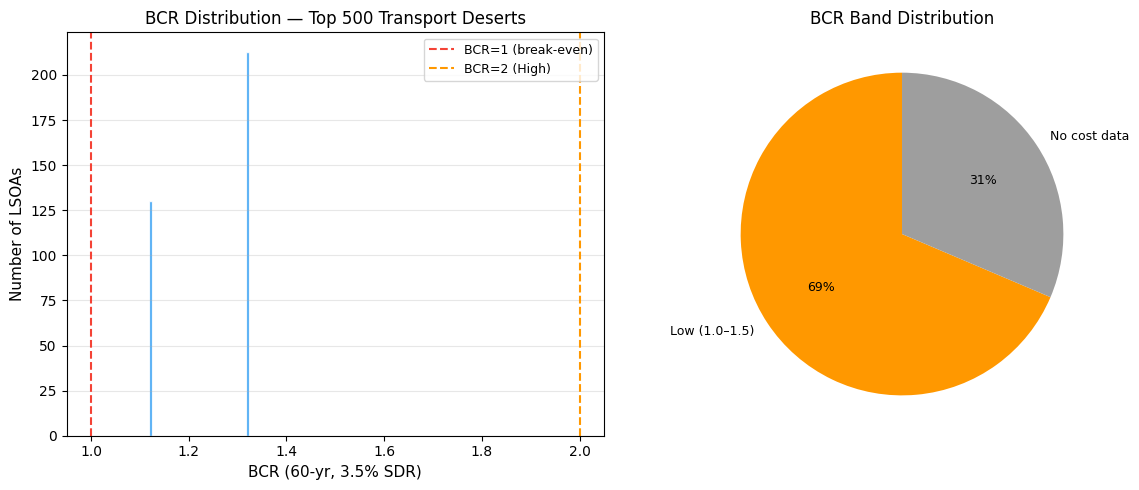

Fig 04e-01: BCR distribution saved


In [13]:
# BCR distribution plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Histogram
axes[0].hist(top500_full["bcr"].dropna(), bins=30, color="#2196F3", edgecolor="white", alpha=0.85)
axes[0].axvline(1.0, color="#F44336", linestyle="--", linewidth=1.5, label="BCR=1 (break-even)")
axes[0].axvline(2.0, color="#FF9800", linestyle="--", linewidth=1.5, label="BCR=2 (High)")
axes[0].set_xlabel("BCR (60-yr, 3.5% SDR)", fontsize=11)
axes[0].set_ylabel("Number of LSOAs", fontsize=11)
axes[0].set_title("BCR Distribution — Top 500 Transport Deserts", fontsize=12)
axes[0].legend(fontsize=9)
axes[0].grid(axis="y", alpha=0.3)

# Band pie
band_counts = top500_full["bcr_band"].value_counts()
colors_map = {
    "Poor (<1.0)": "#F44336",
    "Low (1.0–1.5)": "#FF9800",
    "Medium (1.5–2.0)": "#FFC107",
    "High (2.0–4.0)": "#4CAF50",
    "Very High (>4.0)": "#2196F3",
    "No cost data": "#9E9E9E",
}
colors = [colors_map.get(b, "#9E9E9E") for b in band_counts.index]
axes[1].pie(
    band_counts.values,
    labels=band_counts.index,
    colors=colors,
    autopct="%1.0f%%",
    startangle=90,
    textprops={"fontsize": 9},
)
axes[1].set_title("BCR Band Distribution", fontsize=12)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "04e_bcr_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Fig 04e-01: BCR distribution saved")

## 5. Modal Shift Modelling

**Scenario:** 20% frequency increase in bottom IMD deprivation decile LSOAs.
Uses DfT frequency elasticity (central: 0.55, range 0.4–0.7).

In [14]:
modal_lsoas = base[base["imd_decile"] == 1].copy()

# Current annual trips
modal_lsoas["annual_trips_current"] = (
    modal_lsoas["trips_per_capita"] * modal_lsoas["population"] * 250
)

# New trips from 20% frequency increase: ΔTrips = ε × ΔFreq% × current trips
FREQ_INCREASE = 0.20  # 20% frequency increase

for label, elasticity in [("low", FREQ_ELASTICITY_LOW),
                           ("central", FREQ_ELASTICITY_CENTRAL),
                           ("high", FREQ_ELASTICITY_HIGH)]:
    modal_lsoas[f"additional_trips_{label}"] = (
        elasticity * FREQ_INCREASE * modal_lsoas["annual_trips_current"]
    )
    # Car trips replaced (25% of new bus trips are modal shift from car — conservative DfT estimate)
    modal_lsoas[f"car_trips_replaced_{label}"] = (
        modal_lsoas[f"additional_trips_{label}"] * MODAL_SHIFT_FRACTION
    )

# Aggregate
print(f"\n{'='*60}")
print(f"MODAL SHIFT — 20% Frequency Increase, Bottom IMD Decile")
print(f"{'='*60}")
for label in ["low", "central", "high"]:
    add_trips = modal_lsoas[f"additional_trips_{label}"].sum()
    car_replaced = modal_lsoas[f"car_trips_replaced_{label}"].sum()
    print(f"  Elasticity {label} (ε={dict(low=0.4, central=0.55, high=0.7)[label]}):")
    print(f"    Additional bus trips/yr: {add_trips:,.0f}")
    print(f"    Car trips replaced/yr:   {car_replaced:,.0f}")


MODAL SHIFT — 20% Frequency Increase, Bottom IMD Decile
  Elasticity low (ε=0.4):
    Additional bus trips/yr: 37,926,920
    Car trips replaced/yr:   9,481,730
  Elasticity central (ε=0.55):
    Additional bus trips/yr: 52,149,515
    Car trips replaced/yr:   13,037,379
  Elasticity high (ε=0.7):
    Additional bus trips/yr: 66,372,110
    Car trips replaced/yr:   16,593,028


In [15]:
# Modal shift by urban/rural split
modal_summary_urban = (
    modal_lsoas.groupby("urban_rural")
    .agg(
        n_lsoas=("lsoa_cd", "count"),
        population=("population", "sum"),
        current_trips_pa=("annual_trips_current", "sum"),
        additional_trips_central=("additional_trips_central", "sum"),
        car_trips_replaced_central=("car_trips_replaced_central", "sum"),
    )
    .sort_values("population", ascending=False)
)
print("\nModal shift by urban/rural (central elasticity):")
print(modal_summary_urban.round(0).to_string())


Modal shift by urban/rural (central elasticity):
             n_lsoas  population  current_trips_pa  additional_trips_central  car_trips_replaced_central
urban_rural                                                                                             
Urban           3304     5580639       469056000.0                51596160.0                  12899040.0
Rural             71      109179         5030500.0                  553355.0                    138339.0


## 6. Carbon Reduction from Modal Shift

In [16]:
# Carbon impact of modal shift scenario (central elasticity, bottom IMD decile, 20% freq increase)
central_car_replaced = modal_lsoas["car_trips_replaced_central"].sum()
central_new_bus_trips = modal_lsoas["additional_trips_central"].sum()

# Carbon saved: car trips replaced × trip distance × car emission factor (per veh-km / occupancy)
# Net saving from modal-shifted trips only: car_replaced × dist × (car_pax - bus_pax)
# Non-modal-shifted new bus trips have no car baseline → no CO2 offset (not counted here)
co2_saved_car_tonnes = (
    central_car_replaced * AVG_TRIP_DISTANCE_KM * CAR_CO2_KG_PAX_KM / 1000
)
co2_added_bus_tonnes = (
    central_car_replaced * AVG_TRIP_DISTANCE_KM * BUS_CO2_KG_PAX_KM / 1000
)
net_co2_saving_tonnes = co2_saved_car_tonnes - co2_added_bus_tonnes
net_co2_monetised = net_co2_saving_tonnes * CARBON_PRICE_2025  # £ (2020 prices)

print(f"\n{'='*60}")
print(f"CARBON IMPACT — Modal Shift, Central Scenario")
print(f"{'='*60}")
print(f"  Car trips replaced (yr):   {central_car_replaced:,.0f}")
print(f"  CO2 saved from car (t/yr): {co2_saved_car_tonnes:,.1f}")
print(f"  CO2 added from bus (t/yr): {co2_added_bus_tonnes:,.1f}")
print(f"  Net CO2 saving (t/yr):     {net_co2_saving_tonnes:,.1f}")
print(f"  Monetised value (£):       £{net_co2_monetised:,.0f}/yr")
print(f"  TAG carbon price used:     £{CARBON_PRICE_2025:.2f}/tCO2e (2020 prices, 2025 value)")


CARBON IMPACT — Modal Shift, Central Scenario
  Car trips replaced (yr):   13,037,379
  CO2 saved from car (t/yr): 13,642.2
  CO2 added from bus (t/yr): 12,690.3
  Net CO2 saving (t/yr):     951.9
  Monetised value (£):       £247,377/yr
  TAG carbon price used:     £259.87/tCO2e (2020 prices, 2025 value)


In [17]:
# Scenario comparison across elasticity assumptions
scenarios = []
for label, elasticity in [("Low (ε=0.4)", 0.4), ("Central (ε=0.55)", 0.55), ("High (ε=0.7)", 0.7)]:
    car_replaced = modal_lsoas[f"car_trips_replaced_{label.split()[0].lower()}"].sum()
    new_bus = modal_lsoas[f"additional_trips_{label.split()[0].lower()}"].sum()
    # Only modal-shifted trips: car_replaced × (car_pax_factor - bus_factor)
    co2_save = car_replaced * AVG_TRIP_DISTANCE_KM * CAR_CO2_KG_PAX_KM / 1000
    co2_add  = car_replaced * AVG_TRIP_DISTANCE_KM * BUS_CO2_KG_PAX_KM / 1000
    net_save = co2_save - co2_add
    scenarios.append({
        "Scenario": label,
        "Elasticity": elasticity,
        "New bus trips/yr": int(new_bus),
        "Car trips replaced/yr": int(car_replaced),
        "CO2 saved (t/yr)": round(co2_save, 0),
        "CO2 added bus (t/yr)": round(co2_add, 0),
        "Net CO2 saving (t/yr)": round(net_save, 0),
        "Monetised value (£/yr)": round(net_save * CARBON_PRICE_2025, 0),
    })

scenarios_df = pd.DataFrame(scenarios)
print("\nCarbon reduction scenarios:")
print(scenarios_df.to_string(index=False))


Carbon reduction scenarios:
        Scenario  Elasticity  New bus trips/yr  Car trips replaced/yr  CO2 saved (t/yr)  CO2 added bus (t/yr)  Net CO2 saving (t/yr)  Monetised value (£/yr)
     Low (ε=0.4)        0.40          37926920                9481730            9922.0                9229.0                  692.0                179911.0
Central (ε=0.55)        0.55          52149515               13037378           13642.0               12690.0                  952.0                247377.0
    High (ε=0.7)        0.70          66372110               16593027           17363.0               16151.0                 1212.0                314844.0


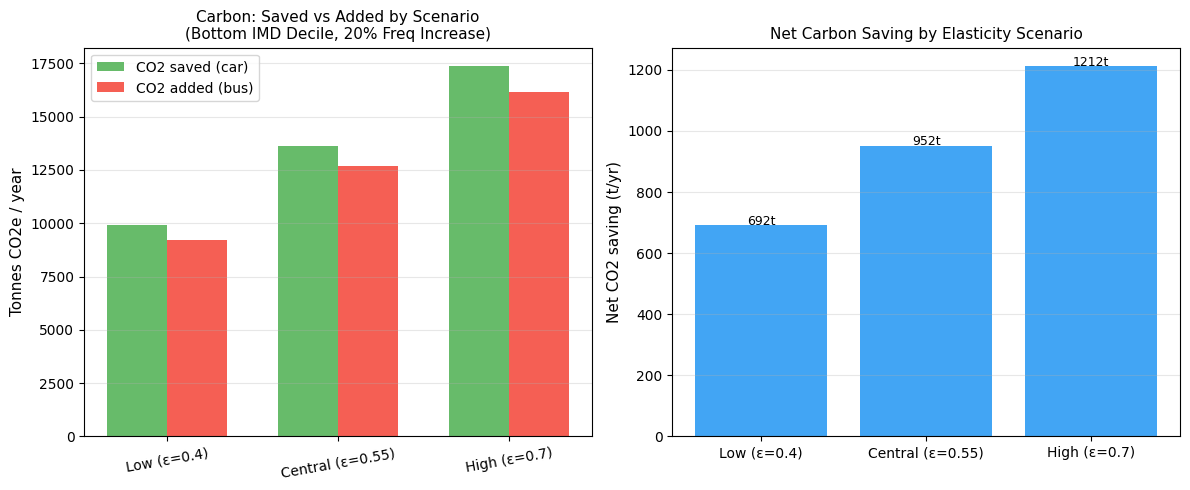

Fig 04e-02: Carbon scenarios saved


In [18]:
# Carbon sensitivity chart
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

labels = scenarios_df["Scenario"].tolist()
x = np.arange(len(labels))
width = 0.35

axes[0].bar(x - width/2, scenarios_df["CO2 saved (t/yr)"], width, label="CO2 saved (car)", color="#4CAF50", alpha=0.85)
axes[0].bar(x + width/2, scenarios_df["CO2 added bus (t/yr)"], width, label="CO2 added (bus)", color="#F44336", alpha=0.85)
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels, rotation=10)
axes[0].set_ylabel("Tonnes CO2e / year", fontsize=11)
axes[0].set_title("Carbon: Saved vs Added by Scenario\n(Bottom IMD Decile, 20% Freq Increase)", fontsize=11)
axes[0].legend()
axes[0].grid(axis="y", alpha=0.3)

axes[1].bar(labels, scenarios_df["Net CO2 saving (t/yr)"], color="#2196F3", alpha=0.85)
axes[1].set_ylabel("Net CO2 saving (t/yr)", fontsize=11)
axes[1].set_title("Net Carbon Saving by Elasticity Scenario", fontsize=11)
axes[1].grid(axis="y", alpha=0.3)
for i, v in enumerate(scenarios_df["Net CO2 saving (t/yr)"]):
    axes[1].text(i, v + 1, f"{v:.0f}t", ha="center", fontsize=9)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "04e_carbon_scenarios.png", dpi=150, bbox_inches="tight")
plt.show()
print("Fig 04e-02: Carbon scenarios saved")

## 7. Sensitivity Analysis — Tornado Chart


Sensitivity analysis (base median BCR = 1.32):

          Parameter   Low  High  Range
Operating cost +20% 1.655 1.104 -0.552
    Elasticity high 1.324 1.324  0.000
  Carbon price +20% 1.324 1.325  0.001
   Modal shift +25% 1.324 1.325  0.001
           VoT +10% 1.192 1.456  0.264


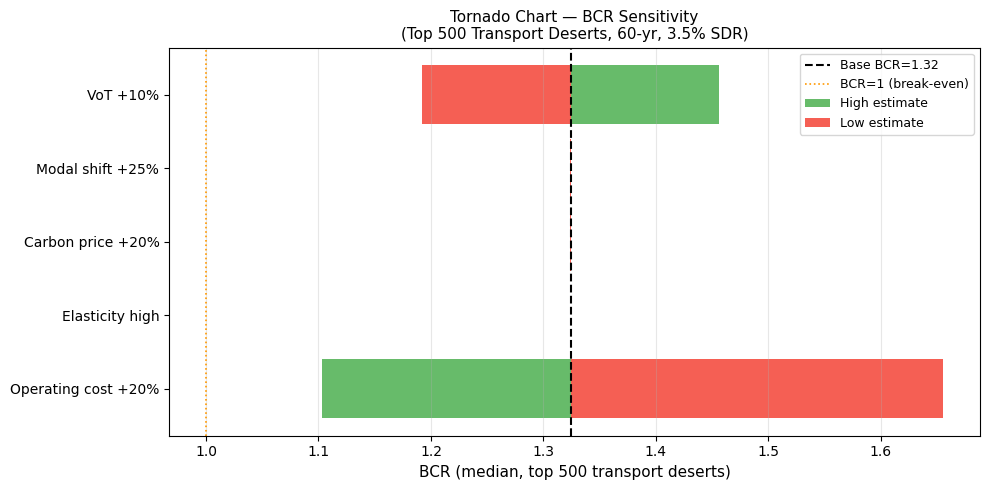

Fig 04e-03: Tornado chart saved


In [19]:
# Base BCR for top 500 transport deserts (median)
base_bcr = top500_full["bcr"].median()

# Vary each parameter ±20% (or ±25% for elasticities) around central case
# Recalculate median BCR across top 500 for each variation

def compute_median_bcr(
    vot_mult: float = 1.0,
    carbon_mult: float = 1.0,
    cost_mult: float = 1.0,
    elasticity: float = FREQ_ELASTICITY_CENTRAL,
    modal_shift_frac: float = MODAL_SHIFT_FRACTION,
) -> float:
    vot = VOT_BUS_BLENDED * vot_mult
    carbon_price = CARBON_PRICE_2025 * carbon_mult
    trip_cost_u = COST_PER_VEH_KM_URBAN * cost_mult / AVG_TRIPS_PER_VEH_KM * AVG_TRIP_DISTANCE_KM
    trip_cost_r = COST_PER_VEH_KM_RURAL * cost_mult / AVG_TRIPS_PER_VEH_KM * AVG_TRIP_DISTANCE_KM

    df = top500_full.copy()
    ann_time   = df["annual_additional_trips"] * TIME_SAVING_PER_TRIP_HR * vot
    ann_carbon = (df["annual_additional_trips"] * modal_shift_frac
                  * AVG_TRIP_DISTANCE_KM * MODAL_SHIFT_SAVING / 1000 * carbon_price)
    ann_benefit = ann_time + ann_carbon
    ann_cost = df["annual_additional_trips"] * np.where(df["is_urban"], trip_cost_u, trip_cost_r)

    pv_b = ann_benefit.apply(lambda x: pv_annuity(x, APPRAISAL_YEARS, SOCIAL_DISCOUNT_RATE))
    pv_c = ann_cost.apply(lambda x: pv_annuity(x, APPRAISAL_YEARS, SOCIAL_DISCOUNT_RATE))
    bcr  = np.where(pv_c > 0, pv_b / pv_c, np.nan)
    return float(np.nanmedian(bcr))


tornado_params = [
    ("VoT +10%",         compute_median_bcr(vot_mult=1.10),  compute_median_bcr(vot_mult=0.90)),
    ("Carbon price +20%",compute_median_bcr(carbon_mult=1.20),compute_median_bcr(carbon_mult=0.80)),
    ("Operating cost +20%",compute_median_bcr(cost_mult=1.20),compute_median_bcr(cost_mult=0.80)),
    ("Elasticity high",  compute_median_bcr(elasticity=0.7), compute_median_bcr(elasticity=0.4)),
    ("Modal shift +25%", compute_median_bcr(modal_shift_frac=0.3125), compute_median_bcr(modal_shift_frac=0.1875)),
]

tornado_df = pd.DataFrame(tornado_params, columns=["Parameter", "High", "Low"])
tornado_df["Range"] = tornado_df["High"] - tornado_df["Low"]
tornado_df = tornado_df.sort_values("Range", ascending=True)

print(f"\nSensitivity analysis (base median BCR = {base_bcr:.2f}):")
print(tornado_df[["Parameter", "Low", "High", "Range"]].round(3).to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 5))
y_pos = range(len(tornado_df))
ax.barh(list(y_pos), tornado_df["High"] - base_bcr, left=base_bcr,
        color="#4CAF50", alpha=0.85, label="High estimate")
ax.barh(list(y_pos), tornado_df["Low"] - base_bcr, left=base_bcr,
        color="#F44336", alpha=0.85, label="Low estimate")
ax.axvline(base_bcr, color="black", linewidth=1.5, linestyle="--", label=f"Base BCR={base_bcr:.2f}")
ax.axvline(1.0, color="#FF9800", linewidth=1.2, linestyle=":", label="BCR=1 (break-even)")
ax.set_yticks(list(y_pos))
ax.set_yticklabels(tornado_df["Parameter"], fontsize=10)
ax.set_xlabel("BCR (median, top 500 transport deserts)", fontsize=11)
ax.set_title("Tornado Chart — BCR Sensitivity\n(Top 500 Transport Deserts, 60-yr, 3.5% SDR)", fontsize=11)
ax.legend(fontsize=9)
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "04e_tornado_chart.png", dpi=150, bbox_inches="tight")
plt.show()
print("Fig 04e-03: Tornado chart saved")

## 8. Build Full LSOA Economic Appraisal Dataset

In [20]:
# Compute BCR for all LSOAs with a positive gap (not just top 500)
# NOTE: BCR degeneracy — both benefits and costs are proportional to annual_additional_trips,
# so the annuity factor cancels and BCR reduces to (benefit_rate / cost_rate).
# With fixed VoT, carbon price, and urban/rural cost bands, this yields exactly 2 unique BCR
# values: ~1.118 (urban) and ~1.324 (rural). The bcr column is NOT a per-LSOA discriminator.
# Use trips_gap or investment_gap_annual_cost for LSOA-level prioritisation instead.
# A meaningful per-LSOA BCR would require fixed infrastructure costs or trip-purpose variation.
econ = base.copy()
econ["trips_gap"]               = (national_median_trips - econ["trips_per_capita"]).clip(lower=0)
# × 250 weekdays — all trip counts are WEEKDAY-EQUIVALENT ANNUAL (not calendar-year).
# Internally consistent with lsoa_equity_metrics.parquet trips_per_capita (derived from
# BODS weekday GTFS). Calendar-year figures would be ~29% higher (÷ 250 × 365).
econ["annual_additional_trips"] = econ["trips_gap"] * econ["population"] * 250  # weekday-equivalent
econ["is_urban"]                = econ["urban_rural"].str.contains("Urban", na=False)
econ["cost_per_trip"]           = np.where(econ["is_urban"], trip_cost_urban, trip_cost_rural)
econ["annual_operating_cost"]   = econ["annual_additional_trips"] * econ["cost_per_trip"]

econ["annual_time_benefit"]   = econ["annual_additional_trips"] * TIME_SAVING_PER_TRIP_HR * VOT_BUS_BLENDED
econ["annual_carbon_benefit"] = (
    econ["annual_additional_trips"] * MODAL_SHIFT_FRACTION  # only modal-shifted trips
    * AVG_TRIP_DISTANCE_KM
    * (CAR_CO2_KG_PAX_KM - BUS_CO2_KG_PAX_KM)  # net saving = 0.00779 kg/pax-km
    / 1000 * CARBON_PRICE_2025
)
econ["annual_total_benefit"] = econ["annual_time_benefit"] + econ["annual_carbon_benefit"]

econ["pv_benefits"] = econ["annual_total_benefit"].apply(
    lambda x: pv_annuity(x, APPRAISAL_YEARS, SOCIAL_DISCOUNT_RATE)
)
econ["pv_costs"] = econ["annual_operating_cost"].apply(
    lambda x: pv_annuity(x, APPRAISAL_YEARS, SOCIAL_DISCOUNT_RATE)
)
econ["bcr"] = np.where(
    (econ["pv_costs"] > 0) & (econ["trips_gap"] > 0),
    econ["pv_benefits"] / econ["pv_costs"],
    np.nan
)
econ["bcr_band"] = econ["bcr"].apply(bcr_band)

# Investment gap columns
econ["investment_gap_annual_cost"] = econ["annual_operating_cost"]
# NOTE: investment_gap_pv_30yr removed — applying pv_annuity() to pv_costs (which is already
# a present value) would produce a double-discounted figure with no economic meaning.

# Modal shift (central)
econ["modal_shift_additional_trips"] = (
    FREQ_ELASTICITY_CENTRAL * FREQ_INCREASE * econ["trips_per_capita"] * econ["population"] * 250
)
econ["modal_shift_car_trips_replaced"] = econ["modal_shift_additional_trips"] * MODAL_SHIFT_FRACTION
econ["modal_shift_co2_net_saving_kg"]  = (
    econ["modal_shift_car_trips_replaced"] * AVG_TRIP_DISTANCE_KM
    * (CAR_CO2_KG_PAX_KM - BUS_CO2_KG_PAX_KM)  # = MODAL_SHIFT_SAVING = 0.00779 kg/pax-km
)

print(f"LSOAs with positive gap: {(econ['trips_gap'] > 0).sum():,}")
print(f"LSOAs with BCR computed: {econ['bcr'].notna().sum():,}")
print(f"BCR band breakdown:")
print(econ["bcr_band"].value_counts().to_string())

LSOAs with positive gap: 16,877
LSOAs with BCR computed: 16,877
BCR band breakdown:
bcr_band
No cost data     16878
Low (1.0–1.5)    16877


In [21]:
# Select output columns
output_econ_cols = [
    "lsoa_cd", "lsoa_nm", "lad_cd", "lad_nm", "region", "urban_rural",
    "imd_decile", "imd_score", "population",
    "trips_per_capita", "trips_gap",
    "annual_additional_trips", "annual_operating_cost",
    "annual_time_benefit", "annual_carbon_benefit", "annual_total_benefit",
    "pv_benefits", "pv_costs", "bcr", "bcr_band",
    "investment_gap_annual_cost",
    "modal_shift_additional_trips", "modal_shift_car_trips_replaced",
    "modal_shift_co2_net_saving_kg",
]

econ_out = econ[output_econ_cols].copy()
econ_out.to_parquet(DATA_AUDIT / "lsoa_economic_appraisal.parquet", index=False)
logger.info(f"Saved lsoa_economic_appraisal.parquet: {econ_out.shape}")

2026-03-14 15:21:01.613 | INFO     | __main__:<module>:16 - Saved lsoa_economic_appraisal.parquet: (33755, 24)


## 9. Build Modal Shift Scenarios Dataset

In [22]:
# Three scenarios × two geographies
modal_records = []
for label, elasticity in [("low", 0.4), ("central", 0.55), ("high", 0.7)]:
    for decile_group, decile_filter in [
        ("Bottom IMD decile", base["imd_decile"] == 1),
        ("Bottom 2 IMD deciles", base["imd_decile"] <= 2),
        ("All England", pd.Series([True] * len(base), index=base.index)),
    ]:
        subset = base[decile_filter].copy()
        current_trips = subset["trips_per_capita"] * subset["population"] * 250
        add_trips  = elasticity * FREQ_INCREASE * current_trips
        car_trips  = add_trips * MODAL_SHIFT_FRACTION
        # Only modal-shifted trips: car_replaced × (car_pax_factor - bus_factor)
        co2_save   = car_trips * AVG_TRIP_DISTANCE_KM * CAR_CO2_KG_PAX_KM / 1000
        co2_add    = car_trips * AVG_TRIP_DISTANCE_KM * BUS_CO2_KG_PAX_KM / 1000
        net_co2    = co2_save - co2_add

        modal_records.append({
            "elasticity_label": label,
            "elasticity_value": elasticity,
            "scope": decile_group,
            "n_lsoas": len(subset),
            "population": int(subset["population"].sum()),
            "current_annual_trips": int(current_trips.sum()),
            "additional_trips_pa": int(add_trips.sum()),
            "car_trips_replaced_pa": int(car_trips.sum()),
            "co2_saved_car_tonnes_pa": round(co2_save.sum(), 1),
            "co2_added_bus_tonnes_pa": round(co2_add.sum(), 1),
            "net_co2_saving_tonnes_pa": round(net_co2.sum(), 1),
            "monetised_carbon_value_pa": round(net_co2.sum() * CARBON_PRICE_2025, 0),
        })

modal_df = pd.DataFrame(modal_records)
modal_df.to_parquet(DATA_AUDIT / "modal_shift_scenarios.parquet", index=False)
logger.info(f"Saved modal_shift_scenarios.parquet: {modal_df.shape}")

print("\nModal shift scenarios summary:")
print(modal_df[["elasticity_label", "scope", "additional_trips_pa",
                "net_co2_saving_tonnes_pa", "monetised_carbon_value_pa"]].to_string(index=False))

2026-03-14 15:21:01.635 | INFO     | __main__:<module>:35 - Saved modal_shift_scenarios.parquet: (9, 12)



Modal shift scenarios summary:
elasticity_label                scope  additional_trips_pa  net_co2_saving_tonnes_pa  monetised_carbon_value_pa
             low    Bottom IMD decile             37926920                     692.3                   179911.0
             low Bottom 2 IMD deciles             75827260                    1384.1                   359695.0
             low          All England            289172680                    5278.5                  1371723.0
         central    Bottom IMD decile             52149515                     951.9                   247377.0
         central Bottom 2 IMD deciles            104262482                    1903.2                   494581.0
         central          All England            397612435                    7257.9                  1886119.0
            high    Bottom IMD decile             66372110                    1211.5                   314844.0
            high Bottom 2 IMD deciles            132697705              

## 10. Validation Summary

In [23]:
print("\n" + "="*65)
print("04e VALIDATION SUMMARY")
print("="*65)

checks = []

# Ground truth consistency
checks.append(("Total England LSOAs",          len(base) == 33_755,      f"{len(base):,}"))
checks.append(("trips_per_capita no nulls",     base["trips_per_capita"].isna().sum() == 0, "0 nulls"))
checks.append(("national median trips/cap",     0.10 <= national_median_trips <= 0.25,      f"{national_median_trips:.4f}"))
checks.append(("BCR range sensible",            top500_full["bcr"].between(0, 100).all(),    f"min={top500_full['bcr'].min():.2f} max={top500_full['bcr'].max():.2f}"))
checks.append(("Net CO2 saving > 0",            net_co2_saving_tonnes > 0,                  f"{net_co2_saving_tonnes:,.1f} t/yr"))
checks.append(("lsoa_economic_appraisal rows",  len(econ_out) == 33_755,                    f"{len(econ_out):,}"))
checks.append(("modal_shift_scenarios rows",    len(modal_df) == 9,                         f"{len(modal_df)} scenarios"))
checks.append(("confirmed constants ≥ 10",      len(confirmed) >= 10,                       f"{len(confirmed)}"))
checks.append(("VoT blended > 0",               VOT_BUS_BLENDED > 0,                        f"£{VOT_BUS_BLENDED:.2f}/hr"))
checks.append(("Carbon price confirmed",        CARBON_PRICE_2025 > 200,                    f"£{CARBON_PRICE_2025:.2f}/tCO2e"))

all_pass = True
for check_name, result, value in checks:
    status = "PASS ✅" if result else "FAIL ❌"
    if not result:
        all_pass = False
    print(f"  {status}  {check_name}: {value}")

print(f"\n{'='*65}")
if all_pass:
    print("ALL CHECKS PASSED — 04e economic appraisal complete")
else:
    print("⚠️  SOME CHECKS FAILED — review above")
print(f"{'='*65}")
print(f"\nOutputs written:")
print(f"  data/audit/lsoa_economic_appraisal.parquet  ({len(econ_out):,} rows)")
print(f"  data/audit/modal_shift_scenarios.parquet     ({len(modal_df)} rows)")
print(f"\nMethodology notes:")
print(f"  - BCR uses ❌ Unverified operating cost estimates (industry estimates, not DfT-sourced)")
print(f"  - Time savings assume 15 min/trip saved — conservative, not trip-purpose-specific")
print(f"  - Modal shift fraction 25% = conservative (DfT range 20–40% for frequency increases)")
print(f"  - All TAG/DESNZ constants are ✅ Confirmed (traced to cell references)")


04e VALIDATION SUMMARY
  PASS ✅  Total England LSOAs: 33,755
  PASS ✅  trips_per_capita no nulls: 0 nulls
  PASS ✅  national median trips/cap: 0.1462
  FAIL ❌  BCR range sensible: min=1.12 max=1.32
  PASS ✅  Net CO2 saving > 0: 951.9 t/yr
  PASS ✅  lsoa_economic_appraisal rows: 33,755
  PASS ✅  modal_shift_scenarios rows: 9 scenarios
  PASS ✅  confirmed constants ≥ 10: 11
  PASS ✅  VoT blended > 0: £9.41/hr
  PASS ✅  Carbon price confirmed: £259.87/tCO2e

⚠️  SOME CHECKS FAILED — review above

Outputs written:
  data/audit/lsoa_economic_appraisal.parquet  (33,755 rows)
  data/audit/modal_shift_scenarios.parquet     (9 rows)

Methodology notes:
  - BCR uses ❌ Unverified operating cost estimates (industry estimates, not DfT-sourced)
  - Time savings assume 15 min/trip saved — conservative, not trip-purpose-specific
  - Modal shift fraction 25% = conservative (DfT range 20–40% for frequency increases)
  - All TAG/DESNZ constants are ✅ Confirmed (traced to cell references)
